# Entrenamiento y evaluacion del modelo

Entrena el `IsolationForest` de deteccion de anomalias (`predictive_monitoring_tool.models.train`) sobre el dataset de entrenamiento (`models.datasets.build_training_dataset()`, 7 dias solo-normal) y lo evalua contra el baseline estadistico de 3-sigma (`models.evaluate`) sobre el set fijo de evaluacion (`models.datasets.build_evaluation_dataset()`, 4 escenarios de anomalia). Todos los numeros de este notebook salen de correr el pipeline real (mismo codigo que `models/train.py`, el entrypoint de CI) — no hay valores hardcodeados.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve

from predictive_monitoring_tool.models.datasets import (
    build_evaluation_dataset,
    build_training_dataset,
    feature_matrix,
)
from predictive_monitoring_tool.models.evaluate import (
    evaluate,
    measure_predict_latency,
    model_scores,
)
from predictive_monitoring_tool.models.train import train_model

## Entrenamiento

`build_training_dataset()` genera 7 dias de trafico normal (`seed=42`, sin escenario) y le aplica `build_features()`. `train_model()` fitea el `IsolationForest` pinneado (`n_estimators=100`, `max_samples=256`, `contamination='auto'`, `random_state=42`) sobre el allowlist de features numericas (excluye `is_anomaly`/`scenario`).

In [2]:
train_df = build_training_dataset()
eval_df = build_evaluation_dataset()

result = train_model(train_df)

print(f"train_df: {train_df.shape}, eval_df: {eval_df.shape}")
print(f"features usadas: {len(result.feature_columns)}")
print(f"hiperparametros: {result.hyperparameters}")

train_df: (10075, 45), eval_df: (5740, 45)
features usadas: 43
hiperparametros: {'random_state': 42, 'contamination': 'auto', 'n_estimators': 100, 'max_samples': 256, 'n_jobs': 1}


## Evaluacion: metricas modelo vs. baseline

`evaluate()` calcula precision/recall/F1/ROC-AUC + matriz de confusion para el modelo (via el umbral calibrado F1-optimo sobre `-score_samples()`, no `predict()`) y para el baseline de 3-sigma, sobre el mismo `eval_df` (4 escenarios: `memory_leak`, `cpu_spike`, `disk_fill`, `service_down`).

In [3]:
metrics, threshold_info = evaluate(result, train_df, eval_df)

print(f"umbral calibrado: {threshold_info.value:.4f} ({threshold_info.criterion})\n")
for name, m in metrics.items():
    print(
        f"{name:>8}: precision={m.precision:.4f} recall={m.recall:.4f} "
        f"f1={m.f1:.4f} roc_auc={m.roc_auc:.4f} confusion={m.confusion}"
    )

umbral calibrado: 0.5485 (f1-optimal over eval score_samples() (grid of 200 percentiles))

   model: precision=0.9153 recall=0.9191 f1=0.9172 roc_auc=0.9906 confusion={'tn': 5485, 'fp': 20, 'fn': 19, 'tp': 216}
baseline: precision=0.8702 recall=0.9702 f1=0.9175 roc_auc=0.9928 confusion={'tn': 5471, 'fp': 34, 'fn': 7, 'tp': 228}


## Curva ROC: modelo vs. baseline

ROC sobre el score continuo de cada detector (`-score_samples()` para el modelo, `max |z|` para el baseline) contra `is_anomaly` real.

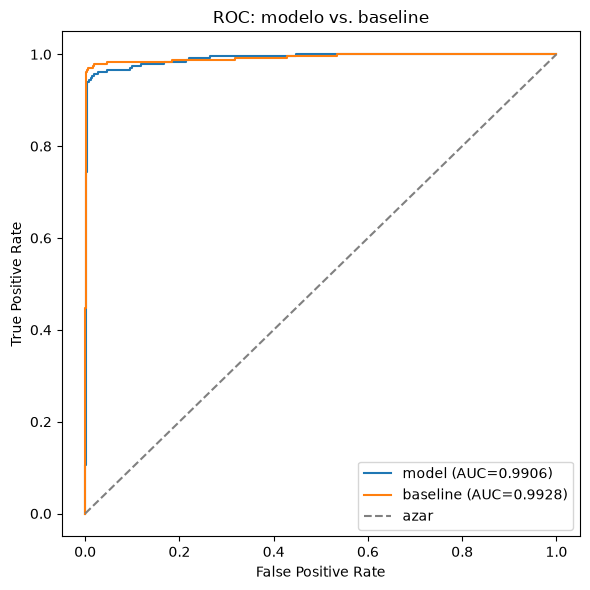

In [4]:
from predictive_monitoring_tool.models.evaluate import baseline_scores, fit_baseline, BASELINE_COLUMNS

y_true = eval_df["is_anomaly"].to_numpy()

X_eval = feature_matrix(eval_df, result.feature_columns)
_, model_score_values = model_scores(result.model, X_eval)

baseline_stats = fit_baseline(train_df[list(BASELINE_COLUMNS)])
_, baseline_score_values = baseline_scores(baseline_stats, eval_df)

fig, ax = plt.subplots(figsize=(6, 6))
for name, scores in [("model", model_score_values), ("baseline", baseline_score_values)]:
    fpr, tpr, _ = roc_curve(y_true, scores)
    ax.plot(fpr, tpr, label=f"{name} (AUC={metrics[name].roc_auc:.4f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="azar")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC: modelo vs. baseline")
ax.legend()
fig.tight_layout()
plt.show()

## Matriz de confusion del modelo

Con el umbral calibrado F1-optimo (`threshold_info.value`), sobre el mismo `eval_df`.

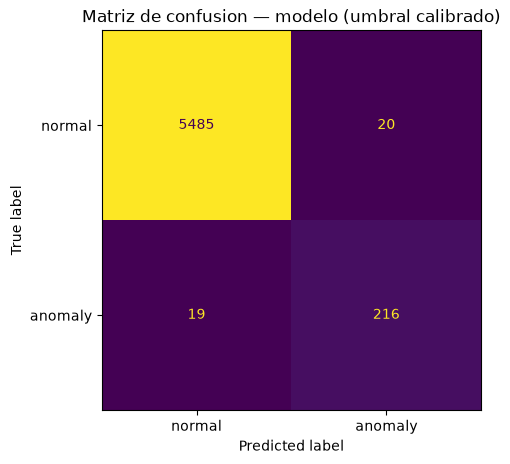

In [5]:
model_flags = model_score_values >= threshold_info.value

fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(
    y_true, model_flags.astype(int), display_labels=["normal", "anomaly"], ax=ax, colorbar=False
)
ax.set_title("Matriz de confusion — modelo (umbral calibrado)")
fig.tight_layout()
plt.show()

## Comparacion visual: modelo vs. baseline

Barras lado a lado de precision/recall/F1/ROC-AUC para ambos detectores. El modelo gana en precision; el baseline gana en recall/F1/ROC-AUC por un margen chico (el criterio de aceptacion solo exige superar al baseline en >=1 metrica, no en todas).

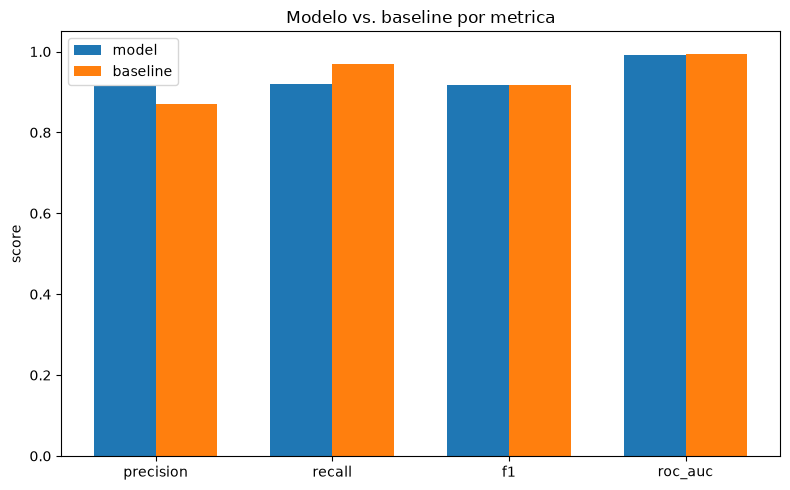

In [6]:
metric_names = ["precision", "recall", "f1", "roc_auc"]
model_values = [getattr(metrics["model"], m) for m in metric_names]
baseline_values = [getattr(metrics["baseline"], m) for m in metric_names]

x = np.arange(len(metric_names))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width / 2, model_values, width, label="model")
ax.bar(x + width / 2, baseline_values, width, label="baseline")
ax.set_xticks(x)
ax.set_xticklabels(metric_names)
ax.set_ylim(0, 1.05)
ax.set_ylabel("score")
ax.set_title("Modelo vs. baseline por metrica")
ax.legend()
fig.tight_layout()
plt.show()

## Latencia de inferencia

`measure_predict_latency()` mide p95/mediana de `model.predict()` sobre una sola fila, 1000 iteraciones tras warm-up, excluyendo el tiempo de feature-building. El SLO pinneado es p95 < 50ms.

In [7]:
row = np.ascontiguousarray(feature_matrix(eval_df.iloc[:1], result.feature_columns), dtype="float64")
latency = measure_predict_latency(result.model, row)

print(f"mediana: {latency['median_ms']:.4f} ms")
print(f"p95: {latency['p95_ms']:.4f} ms (SLO: < 50 ms)")

mediana: 11.4483 ms
p95: 17.0973 ms (SLO: < 50 ms)
